In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('loan_data_new.csv')

In [3]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


In [5]:
df.isnull().sum()

,0
Age,0
Gender,0
Education,0
Person Income,0
Employee Experience,0
Home Onwership,0
Loan Amount,0
Loan Intent,0
Loan interest Rate,0
Loan percentage,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  object 
 2   Education            45000 non-null  object 
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  object 
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  object 
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  object 
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 4.8+ MB


In [21]:
df['Loan_Status_Label'] = df['Loan Status'].map({
    0: 'Approved',
    1: 'Rejected'
})

In [12]:
df['LoanAmount_Group'] = pd.cut(
    df['Loan Amount'],
    bins=[0, 5000, 10000, 20000, 50000],
    labels=[
        '0-5K',
        '5K-10K',
        '10K-20K',
        '20K+'
    ]
)

/tmp/ipykernel_572/1056903874.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Amount_Status=df.groupby('LoanAmount_Group')['Loan_Status_Label'].value_counts(normalize=True).mul(100).rename("Percentage").reset_index()


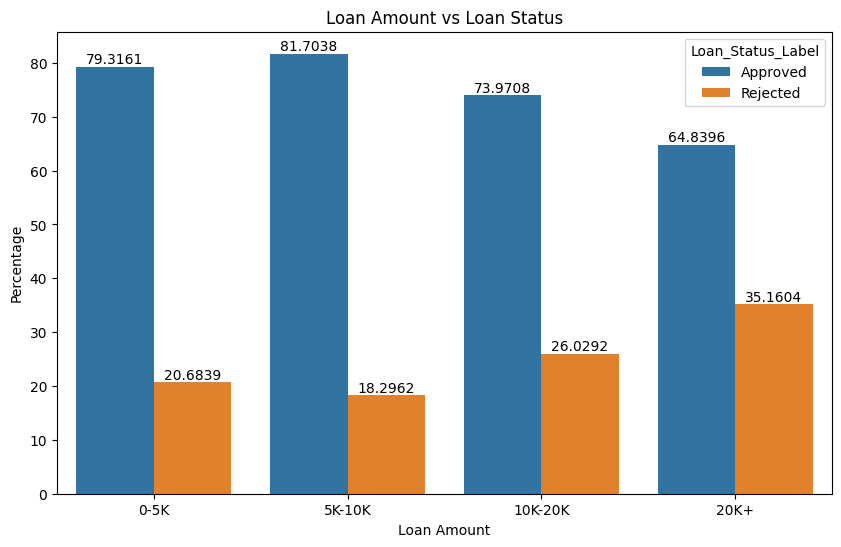

In [22]:
Amount_Status=df.groupby('LoanAmount_Group')['Loan_Status_Label'].value_counts(normalize=True).mul(100).rename("Percentage").reset_index()
plt.figure(figsize=(10,6))
ax=sns.barplot(x='LoanAmount_Group',y='Percentage',hue='Loan_Status_Label',data=Amount_Status)
for i in ax.containers:
    ax.bar_label(i,)
plt.title('Loan Amount vs Loan Status')
plt.xlabel('Loan Amount')
plt.ylabel('Percentage')
plt.show()

In [17]:
df['Person Income'].unique()

array([71948, 12282, 12438, ..., 31924, 56942, 33164])

In [18]:
df['Income_Group'] = pd.cut(
    df['Person Income'],
    bins=[0, 25000, 50000, 75000, 100000, 200000],
    labels=[
        '0-25K',
        '25K-50K',
        '50K-75K',
        '75K-100K',
        '100K+'
    ]
)

/tmp/ipykernel_572/2766912402.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Income_Status=df.groupby('Income_Group')['Loan_Status_Label'].value_counts(normalize=True).mul(100).rename("Percentage").reset_index()


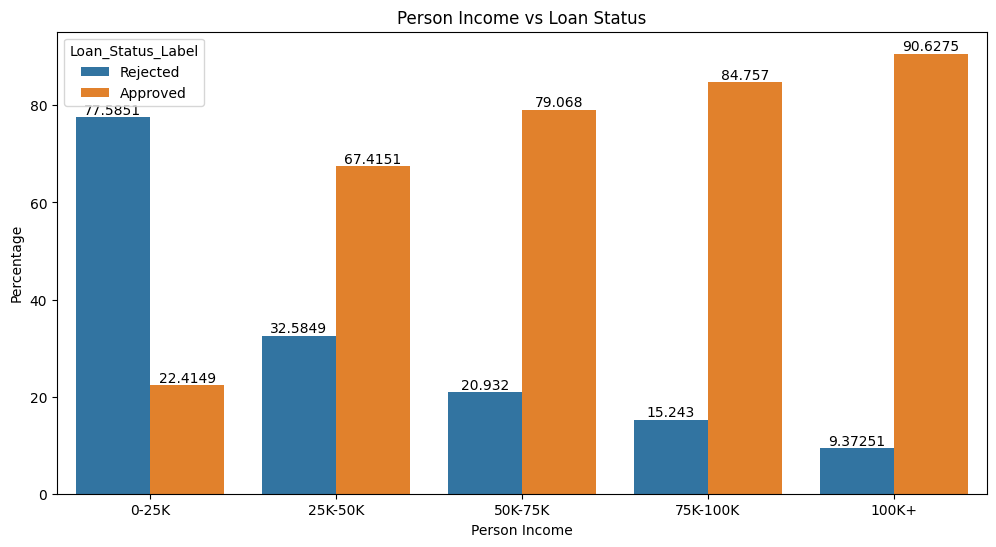

In [24]:
Income_Status=df.groupby('Income_Group')['Loan_Status_Label'].value_counts(normalize=True).mul(100).rename("Percentage").reset_index()
plt.figure(figsize=(12,6))
ax=sns.barplot(x='Income_Group',y='Percentage',hue='Loan_Status_Label',data=Income_Status)
for i in ax.containers:
    ax.bar_label(i,)
plt.title('Person Income vs Loan Status')
plt.xlabel('Person Income')
plt.ylabel('Percentage')
plt.show()

### 💡 Insight 1: Higher Applicant Income Is Associated with Greater Loan Approval

**Observation:**

Applicants with higher annual incomes were considerably more likely to have their loans approved. The approval rate increased consistently from **22.4%** for applicants earning **0–25K** to **90.6%** for applicants earning **100K+**, while rejection rates declined across the income groups.

**Business Insight:**

The supporting analysis indicates that approval rates decrease as the requested loan amount increases. Applicants requesting loans above **20K** experienced the highest rejection rate (**35.2%**), whereas smaller loan amounts had the highest approval rates. This suggests that lenders evaluate both an applicant's repayment capacity (income) and the financial risk associated with larger loan requests when making approval decisions.

**Recommendation:**

Financial institutions should assess loan affordability by balancing applicant income with the requested loan amount. Applicants with lower incomes requesting larger loans may benefit from smaller loan offers, flexible repayment plans, or additional financial assessments to improve approval outcomes while managing lending risk.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  45000 non-null  int64   
 1   Gender               45000 non-null  object  
 2   Education            45000 non-null  object  
 3   Person Income        45000 non-null  int64   
 4   Employee Experience  45000 non-null  int64   
 5   Home Onwership       45000 non-null  object  
 6   Loan Amount          45000 non-null  int64   
 7   Loan Intent          45000 non-null  object  
 8   Loan interest Rate   45000 non-null  float64 
 9   Loan percentage      45000 non-null  float64 
 10  Credit History       45000 non-null  int64   
 11  Credit Score         45000 non-null  int64   
 12  Previous Loan        45000 non-null  object  
 13  Loan Status          45000 non-null  int64   
 14  LoanAmount_Group     45000 non-null  category
 15  Income_Group       

In [26]:
df["Loan Intent"].unique()

array(['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT',
       'DEBTCONSOLIDATION'], dtype=object)

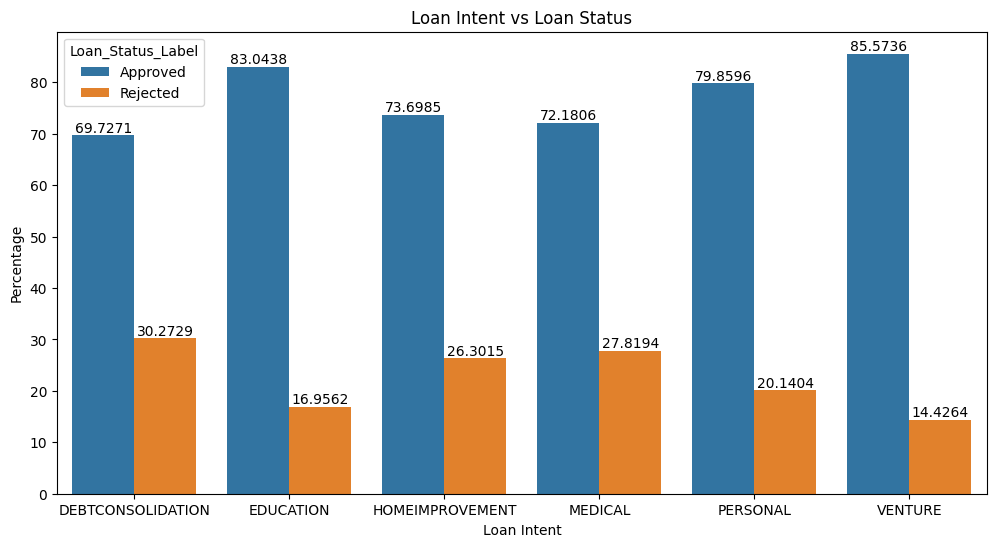

In [28]:
Intent_Status=df.groupby('Loan Intent')['Loan_Status_Label'].value_counts(normalize=True).mul(100).rename("Percentage").reset_index()
plt.figure(figsize=(12,6))
ax=sns.barplot(x='Loan Intent',y='Percentage',hue='Loan_Status_Label',data=Intent_Status)
for i in ax.containers:
    ax.bar_label(i,)
plt.title('Loan Intent vs Loan Status')
plt.xlabel('Loan Intent')
plt.ylabel('Percentage')
plt.show()

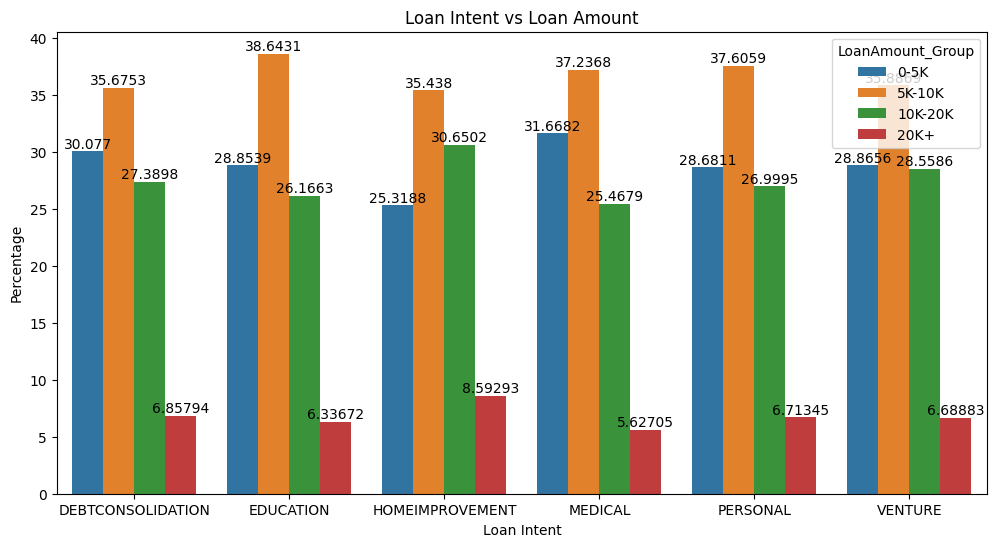

In [30]:
Intent_Amount=df.groupby('Loan Intent')['LoanAmount_Group'].value_counts(normalize=True).mul(100).rename("Percentage").reset_index()
plt.figure(figsize=(12,6))
ax=sns.barplot(x='Loan Intent',y='Percentage',hue='LoanAmount_Group',data=Intent_Amount)
for i in ax.containers:
    ax.bar_label(i,)
plt.title('Loan Intent vs Loan Amount')
plt.xlabel('Loan Intent')
plt.ylabel('Percentage')
plt.show()

### 💡 Insight 2: Loan Approval Varies Across Different Loan Purposes

**Observation:**

Loan approval rates differed across loan purposes. Applicants seeking loans for **Venture (85.6%)** and **Education (83.0%)** recorded the highest approval rates, while **Debt Consolidation (69.7%)** and **Medical (72.2%)** loans experienced comparatively lower approval rates.

**Business Insight:**

The supporting analysis shows that applicants across different loan purposes request broadly similar loan amount distributions, with the majority of applications falling in the **5K–10K** range and relatively few exceeding **20K**. Since requested loan amounts are largely comparable across loan intents, the differences in approval rates are likely associated with additional applicant characteristics or lender risk assessments beyond the loan purpose itself.

**Recommendation:**

Financial institutions should continue evaluating loan applications using a combination of applicant income, repayment capacity, credit history, and requested loan amount rather than relying solely on loan purpose. Applicants with traditionally lower approval rates may benefit from additional financial assessment or customized lending products.

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  45000 non-null  int64   
 1   Gender               45000 non-null  object  
 2   Education            45000 non-null  object  
 3   Person Income        45000 non-null  int64   
 4   Employee Experience  45000 non-null  int64   
 5   Home Onwership       45000 non-null  object  
 6   Loan Amount          45000 non-null  int64   
 7   Loan Intent          45000 non-null  object  
 8   Loan interest Rate   45000 non-null  float64 
 9   Loan percentage      45000 non-null  float64 
 10  Credit History       45000 non-null  int64   
 11  Credit Score         45000 non-null  int64   
 12  Previous Loan        45000 non-null  object  
 13  Loan Status          45000 non-null  int64   
 14  LoanAmount_Group     45000 non-null  category
 15  Income_Group       

In [47]:
df['LoanPercent_Group'] = pd.cut(
    df['Loan percentage'],
    bins=[0,0.10,0.20,0.30,0.40,1.0],
    labels=[
        '0-10%',
        '10-20%',
        '20-30%',
        '30-40%',
        '40%+'
    ]
)

In [48]:
df['InterestRate_Group'] = pd.cut(
    df['Loan interest Rate'],
    bins=[0,5,10,15,20,30],
    labels=[
        '0-5%',
        '5-10%',
        '10-15%',
        '15-20%',
        '20%+'
    ]
)

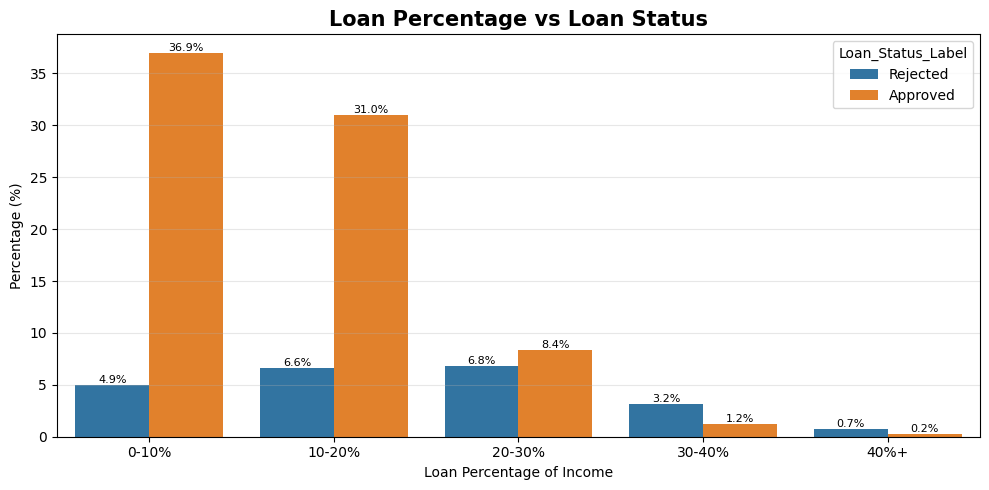

In [49]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x='LoanPercent_Group',
    hue='Loan_Status_Label',
    stat='percent'
)

plt.title('Loan Percentage vs Loan Status',fontsize=15,fontweight='bold')
plt.xlabel('Loan Percentage of Income')
plt.ylabel('Percentage (%)')

plt.grid(axis='y',alpha=.3)

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%',fontsize=8)

plt.tight_layout()
plt.show()

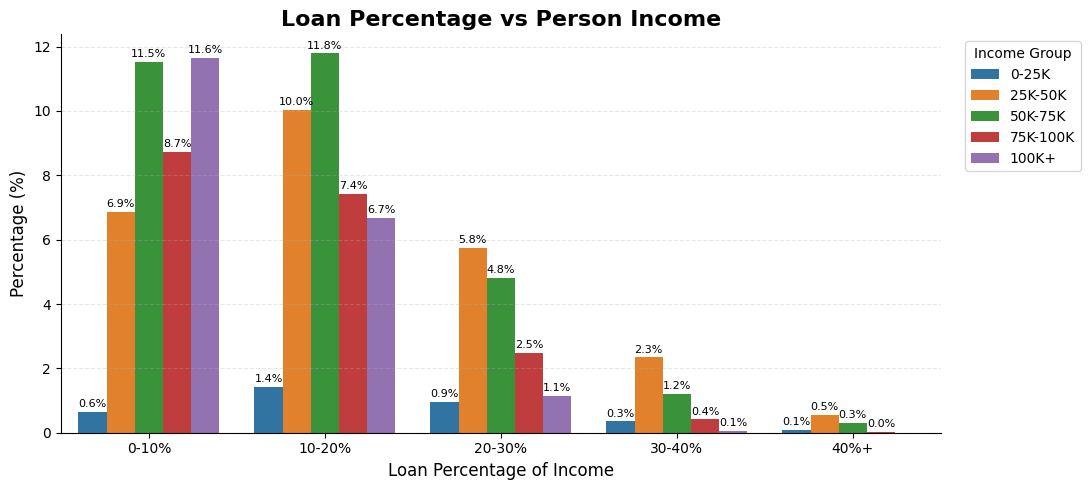

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11,5))

ax = sns.countplot(
    data=df,
    x='LoanPercent_Group',
    hue='Income_Group',
    stat='percent'
)

# ---------- Formatting ----------
plt.title(
    'Loan Percentage vs Person Income',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Loan Percentage of Income', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.legend(
    title='Income Group',
    bbox_to_anchor=(1.02,1),
    loc='upper left',
    frameon=True
)

# ---------- Percentage Labels ----------
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        fontsize=8,
        padding=2
    )

sns.despine()

plt.tight_layout()
plt.show()

### 💡 Insight 3: Lower Loan-to-Income Ratios Are Associated with Higher Loan Approval

**Observation:**

Applicants with a lower **Loan Percentage of Income** were considerably more likely to have their loans approved. The highest approval rate was observed among applicants whose loan amount represented only **0–10% of their annual income**, while approval rates steadily declined as the loan percentage increased. Applicants requesting loans exceeding **30% of their annual income** experienced substantially lower approval rates.

**Business Insight:**

The supporting analysis shows that applicants with **lower loan-to-income ratios** are primarily concentrated in the **higher income groups (50K–75K, 75K–100K, and 100K+)**, whereas higher loan-to-income ratios are more common among applicants in the lower income groups. This suggests that applicants with stronger earning capacity require a smaller proportion of their income to repay the loan, reducing financial risk from the lender's perspective and increasing the likelihood of loan approval.

**Recommendation:**

Financial institutions should continue evaluating the **loan-to-income ratio** as an important affordability indicator during loan assessment. Applicants with higher loan burdens relative to their income may benefit from smaller loan offers, extended repayment terms, or additional financial evaluation to reduce default risk while improving approval opportunities.

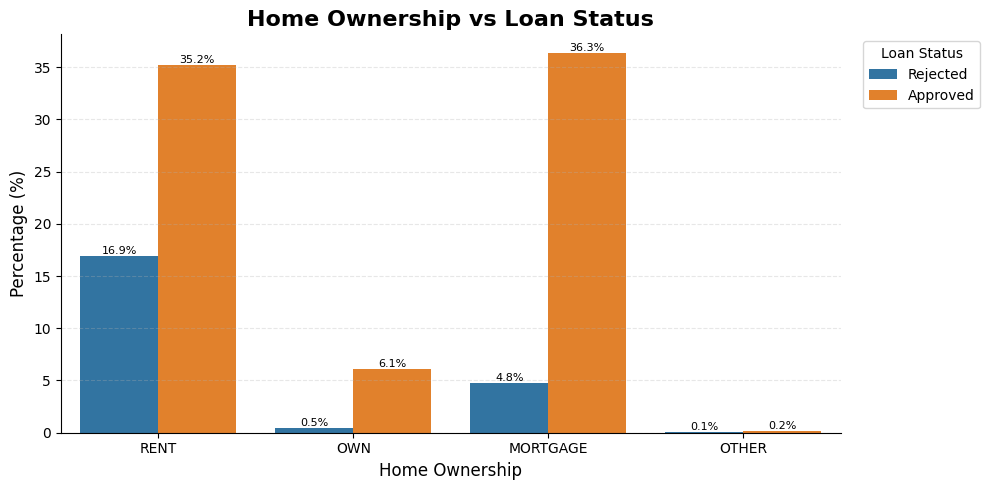

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x='Home Onwership',
    hue='Loan_Status_Label',
    stat='percent'
)

plt.title(
    'Home Ownership vs Loan Status',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Home Ownership', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.legend(
    title='Loan Status',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8)

sns.despine()

plt.tight_layout()
plt.show()

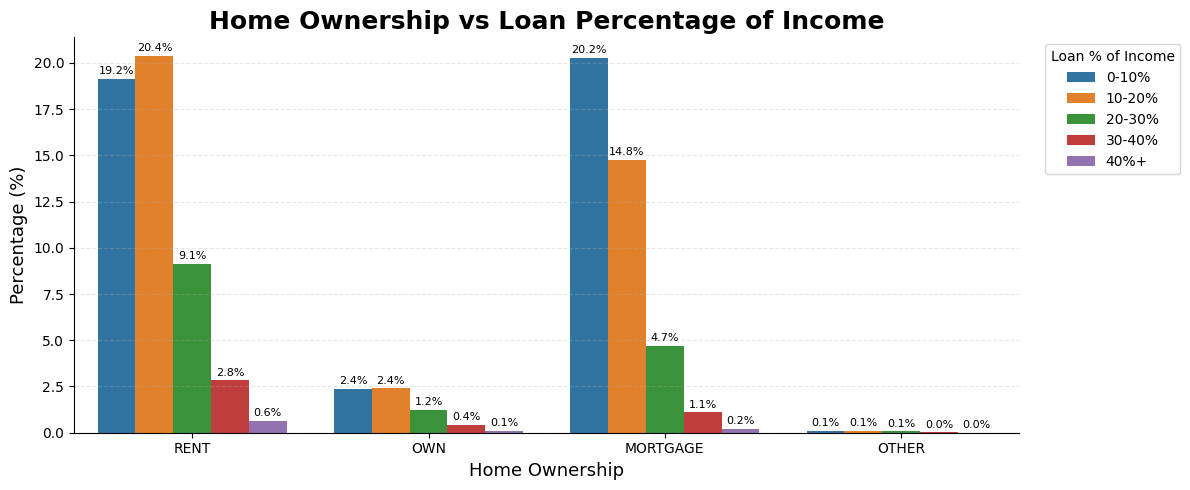

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=df,
    x='Home Onwership',
    hue='LoanPercent_Group',
    stat='percent'
)

plt.title(
    'Home Ownership vs Loan Percentage of Income',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Home Ownership',
    fontsize=13
)

plt.ylabel(
    'Percentage (%)',
    fontsize=13
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title='Loan % of Income',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        fontsize=8,
        padding=2
    )

sns.despine()

plt.tight_layout()

plt.show()

Observation

Applicants with Mortgage home ownership showed the highest loan approval rate, while Rent applicants accounted for a larger share of loan rejections. The supporting analysis indicates that mortgage holders are more concentrated in higher income groups, whereas renters are primarily concentrated in lower and middle income categories.

Business Insight

Mortgage holders tend to have higher income levels, suggesting greater financial stability and repayment capacity. This makes them lower-risk applicants and increases their likelihood of loan approval. In contrast, renters are more represented in lower income groups, which may contribute to relatively higher rejection rates.

Recommendation

Financial institutions should consider home ownership together with applicant income when assessing loan applications. Evaluating these factors alongside repayment capacity can help improve lending decisions while maintaining a balanced credit risk profile.

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  45000 non-null  int64   
 1   Gender               45000 non-null  object  
 2   Education            45000 non-null  object  
 3   Person Income        45000 non-null  int64   
 4   Employee Experience  45000 non-null  int64   
 5   Home Onwership       45000 non-null  object  
 6   Loan Amount          45000 non-null  int64   
 7   Loan Intent          45000 non-null  object  
 8   Loan interest Rate   45000 non-null  float64 
 9   Loan percentage      45000 non-null  float64 
 10  Credit History       45000 non-null  int64   
 11  Credit Score         45000 non-null  int64   
 12  Previous Loan        45000 non-null  object  
 13  Loan Status          45000 non-null  int64   
 14  LoanAmount_Group     45000 non-null  category
 15  Income_Group       

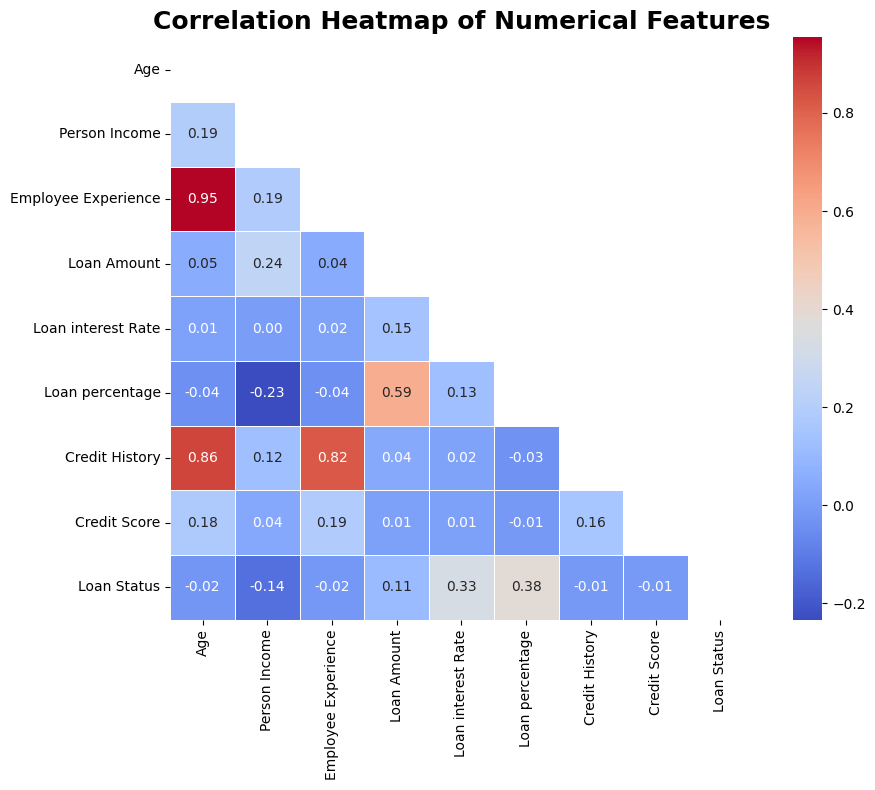

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[
    [
        'Age',
        'Person Income',
        'Employee Experience',
        'Loan Amount',
        'Loan interest Rate',
        'Loan percentage',
        'Credit History',
        'Credit Score',
        'Loan Status'
    ]
].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title(
    'Correlation Heatmap of Numerical Features',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Correlation Heatmap Analysis

The correlation heatmap provides an overview of the linear relationships between the numerical features in the dataset. Correlation values range from -1 to +1, where values closer to +1 indicate a strong positive relationship, values closer to -1 indicate a strong negative relationship, and values near 0 indicate little or no linear relationship.

Key Observations
Person Income shows a positive relationship with Loan Amount, indicating that applicants with higher incomes generally apply for larger loans.
Employee Experience is positively correlated with Age, suggesting that older applicants tend to have more work experience.
Loan Percentage and Loan Status exhibit a stronger relationship than most demographic variables, highlighting the importance of loan affordability in approval decisions.
Credit Score and Credit History demonstrate a meaningful relationship with loan approval, reinforcing the importance of an applicant's credit profile during the lending process.
Most other numerical variables show weak to moderate correlations, indicating that loan approval decisions are influenced by multiple factors rather than a single attribute.
Business Insight

The correlation analysis suggests that financial characteristics, such as income, loan affordability, credit history, and credit score, have a greater influence on loan approval than demographic attributes like age. This reinforces the findings from the earlier visualizations, where applicants with stronger financial profiles were consistently more likely to receive loan approval.

Executive Summary

This exploratory data analysis examined the key factors influencing loan approval decisions using applicant demographics, financial characteristics, and loan-related attributes. The analysis identified several important relationships between applicant income, loan affordability, home ownership, and loan approval outcomes. By combining statistical exploration with business-oriented visualizations, the study highlights the major drivers that financial institutions may consider when evaluating loan applications.

Key Findings
Applicants with higher incomes were more likely to receive loan approval.
A lower Loan Percentage of Income was associated with higher approval rates, indicating stronger repayment capacity.
Loan Intent influenced approval rates, suggesting that the purpose of borrowing affects lending decisions.
Applicants with Mortgage home ownership generally showed higher approval rates and were more concentrated in higher income groups, indicating greater financial stability.
The correlation analysis showed that financial variables such as income, loan amount, and loan percentage of income have stronger relationships with loan approval than demographic characteristics.

Business Recommendations
Continue prioritizing loan affordability by evaluating the loan amount relative to the applicant's income.
Include income verification and repayment capacity as primary factors in loan approval decisions.
Consider home ownership as an additional indicator of financial stability, while evaluating it alongside income and repayment ability.
Apply risk-based lending strategies by adjusting approval criteria based on loan purpose, financial profile, and repayment capacity.
Regularly monitor applicant financial characteristics to maintain balanced lending decisions while minimizing default risk.

Conclusion

The analysis demonstrates that loan approval decisions are primarily influenced by an applicant's financial strength rather than demographic characteristics. Higher income, lower loan-to-income ratios, and stronger financial stability were consistently associated with higher approval rates. These findings provide practical insights that can help financial institutions improve credit risk assessment and make more informed lending decisions.